In [3]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
# from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score, mean_squared_error

df = pd.read_csv('Housing.csv')
df.head()



,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


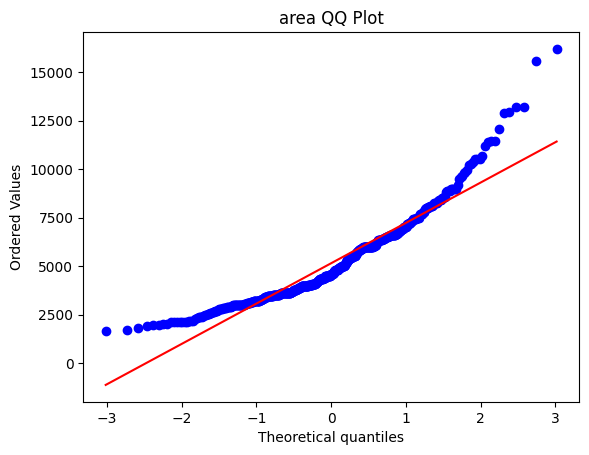

In [11]:
from scipy import stats

stats.probplot(df['area'], dist='norm', plot=plt)
plt.title("area QQ Plot")
plt.show()


In [23]:
from scipy.stats import zscore

def outlier_display(df, column):
    plots = [sns.boxplot, sns.stripplot, sns.swarmplot]
    for p in plots:
        p(x=column, data=df)
        plt.show()

def IQR_remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    cleaned_df = df[(df[column] >= lower) & (df[column] <= upper)]
    outlier_display(cleaned_df, column)
    return cleaned_df


# percental outlayer  removers  method
def Percent_outliers_removel(df, column):
    P5 = np.percentile(df[column], 5)
    P95 = np.percentile(df[column], 95)
    no_outliers = df[(df[column] >= P5) & (df[column] <= P95)]
    outlier_display(no_outliers, column)
    return no_outliers


#z score outlayer  removers  method
def z_score_outliers_removel(df, column):
    df['z_score'] = zscore(df[column])
    no_outliers = df[df['z_score'].abs() <= 2]
    outlier_display(no_outliers, column)
    return no_outliers

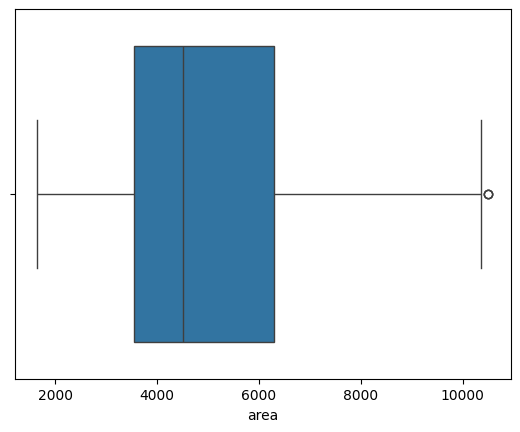

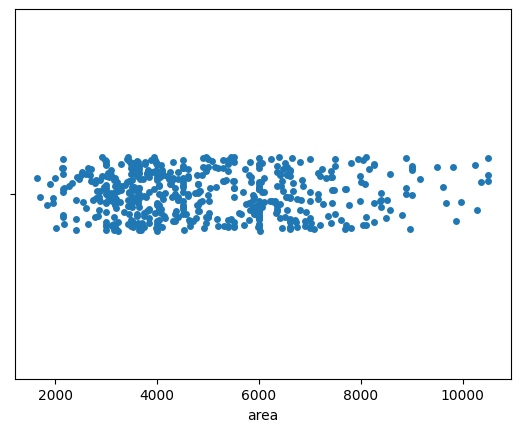

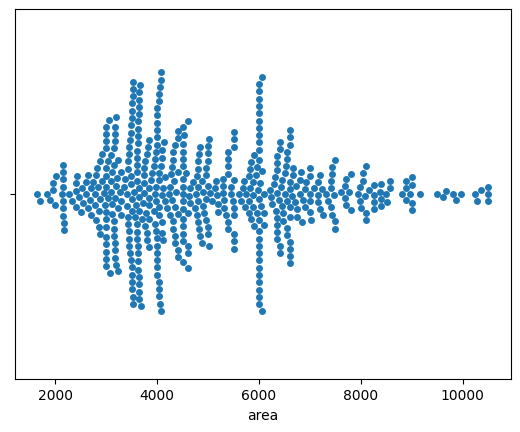

In [24]:
clean_df=IQR_remove_outliers(df, 'area')

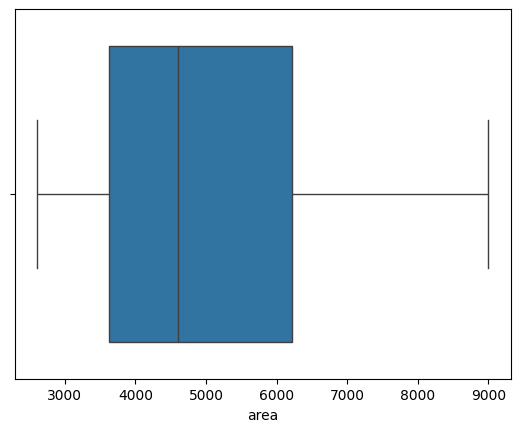

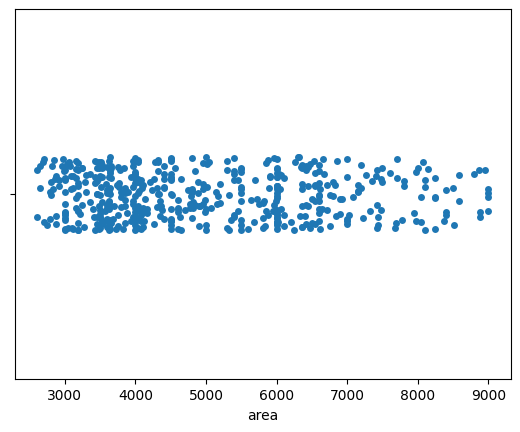

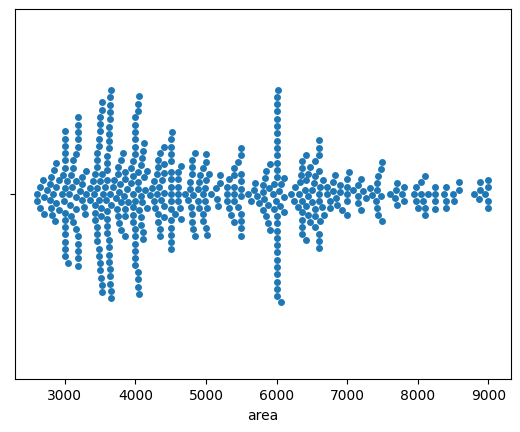

In [25]:
clean_df1 = Percent_outliers_removel(df, 'area')

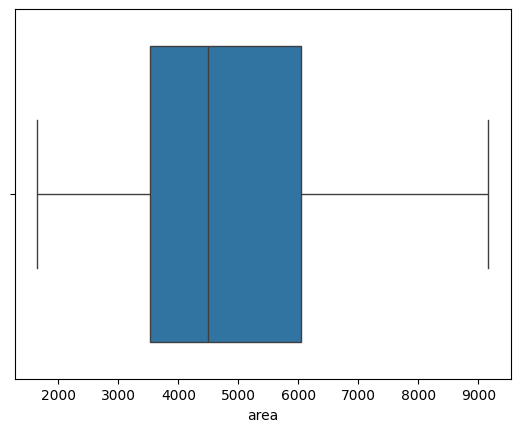

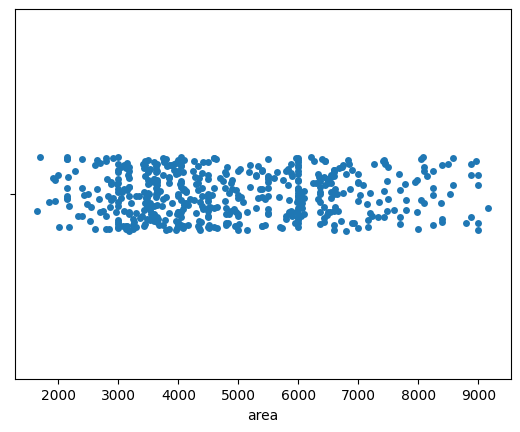

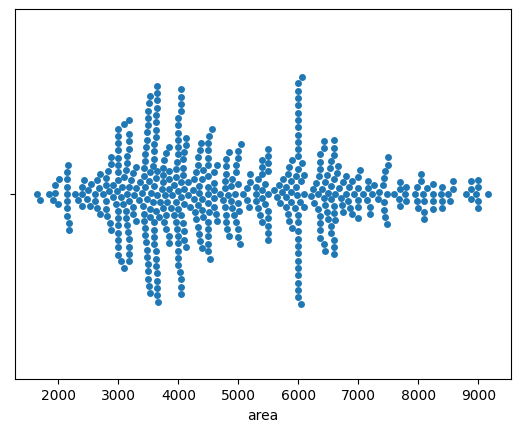

In [26]:
clean_df2 = z_score_outliers_removel(df, 'area')

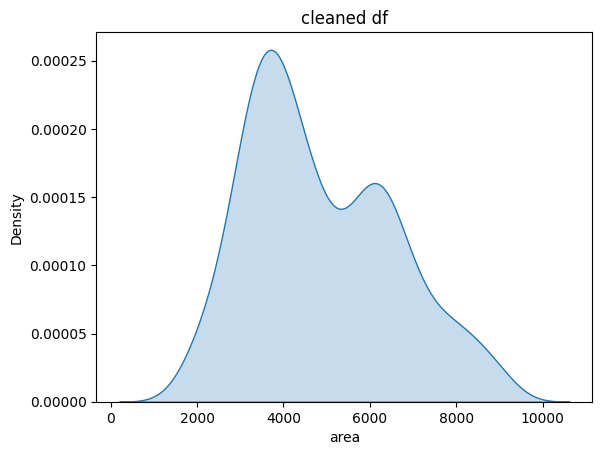

In [33]:
sns.kdeplot(x="area",data=clean_df2,fill=True)
plt.title("cleaned df")
plt.show()

In [36]:
from scipy.stats import kurtosis
from scipy.stats import skew
print("skew with out outlier ",skew(clean_df['area']))
print("kurtosis with out outlier ",kurtosis(clean_df['area']))
print("skew with out outlier ",skew(clean_df1['area']))
print("kurtosis with out outlier ",kurtosis(clean_df1['area']))

#clean_df2 is best for symmetry (lowest skew).
print("skew with out outlier ",skew(clean_df2['area']))
print("kurtosis with out outlier ",kurtosis(clean_df2['area']))

skew with out outlier  0.6815715601949651
kurtosis with out outlier  -0.09168222374373691
skew with out outlier  0.5668927633438224
kurtosis with out outlier  -0.6589282958730291
skew with out outlier  0.48334293355838537
kurtosis with out outlier  -0.6074158471081934


In [47]:
clean_df2

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,z_score
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,1.046726
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,1.757010
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,1.083624
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,1.046726
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished,1.083624
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished,-0.991879
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished,-1.268613
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished,-0.705921
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished,-1.033389


In [50]:
feature=clean_df2[["area", "bedrooms", "bathrooms", "stories", "parking"]]
#X=clean_df2[["area"]]
X=feature
y = clean_df2["price"]

In [51]:
#Train Test Splight
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [52]:
#Train Lener reg
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [53]:
#model coeficient
print("Slot(m)",model.coef_[0])
print("Intersept (c)", model.intercept_ )

Slot(m) 426.56521078535764
Intersept (c) -344255.88885365706


In [54]:
#model predection
y_pred=model.predict(x_test)
y_pred


array([3924179.40809014, 5449678.44989102, 6475064.27480169,
       4359235.31415893, 6525645.62083976, 5668876.3308835 ,
       4494127.16705057, 3658916.92323094, 4713535.52917428,
       3023269.24401337, 4977899.83578154, 4328603.99969781,
       2844111.85548352, 3253679.97298485, 5426716.39157321,
       5190351.54509775, 4929995.43175778, 6907062.94344838,
       4357626.29959926, 3671628.05994098, 3684510.83587806,
       6324367.91759836, 5465292.83546001, 5398510.92906291,
       4305077.39795723, 5025785.70236725, 3966795.3202364 ,
       3305659.85245137, 3144905.84423458, 4507695.87308028,
       3701573.44430947, 2997675.33136625, 4310785.46727366,
       6420633.63716924, 4508362.10168462, 5136692.65717145,
       4883678.41092644, 6109326.85290945, 4512864.30518904,
       3552189.80092108, 6448360.37587028, 4717635.91083215,
       7143352.81784011, 3381543.4121408 , 2696946.85776257,
       4354132.39719755, 3199018.54975503, 4700507.78725335,
       3040331.85244478,

In [55]:
#model evaluation
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Absolute Error: 1075630.9381319224
Mean Squared Error: 2218416570152.422
Root Mean Squared Error: 1489434.9835264452
R2 Score: 0.5144570594931139


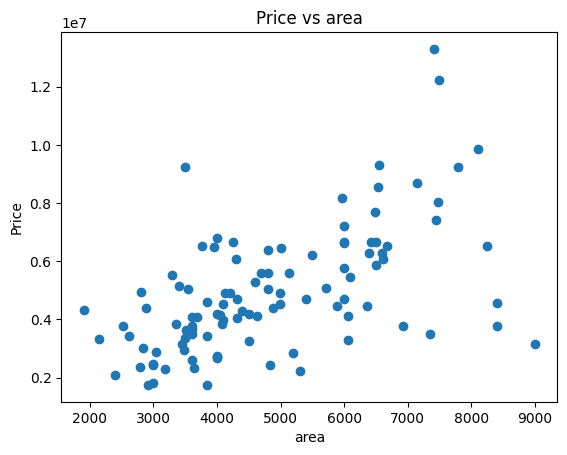

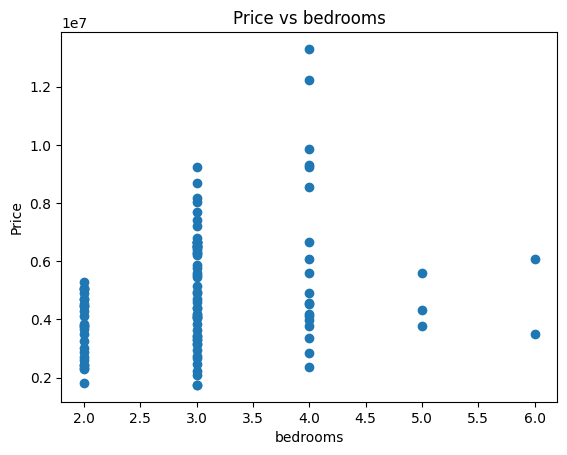

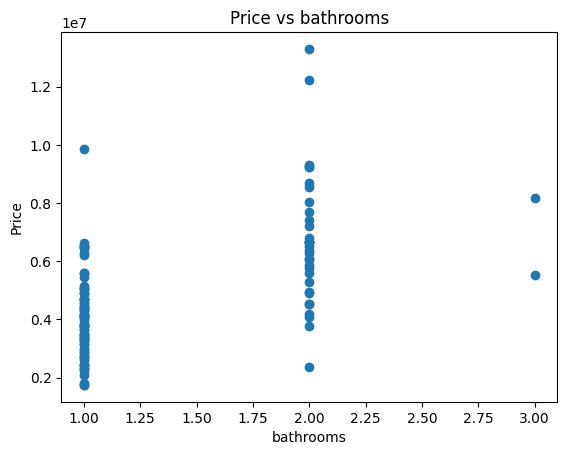

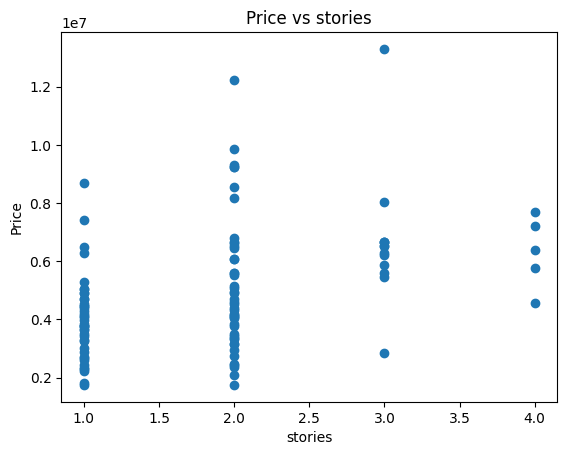

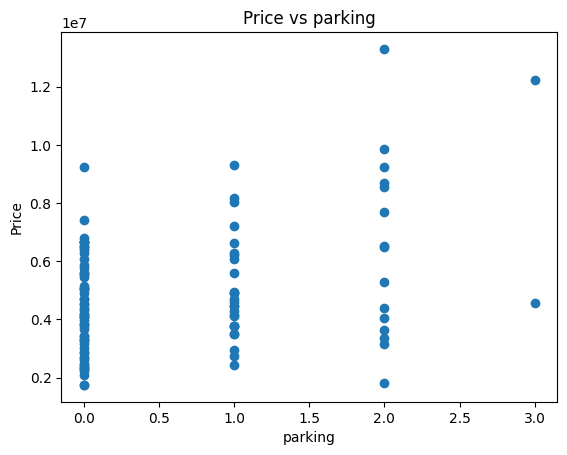

In [66]:
features = ["area", "bedrooms", "bathrooms", "stories", "parking"]
for f in features:
    plt.scatter(x_test[f], y_test)
    plt.title(f"Price vs {f}")
    plt.xlabel(f)
    plt.ylabel("Price")
    plt.show()


ValueError: x and y must be the same size

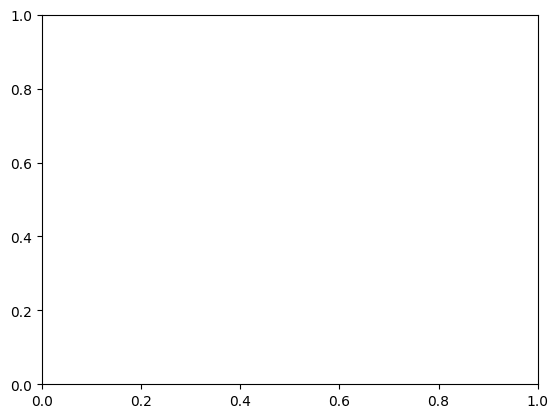

In [67]:
#vishulaization
plt.scatter(x_test,y_test)
plt.plot(x_test,y_pred)
plt.show()

In [64]:
#prerdect new house print_exception
new_are = 7500
new_house = pd.DataFrame({
    "area": [7500],
    "bedrooms": [4],
    "bathrooms": [2],
    "stories": [3],
    "parking": [2]
})
predicted_price = model.predict(new_house)
print(predicted_price[0])
#

7699516.910886888
